# Notebook 05 — Ingeniería y transformación de variables

En este notebook estudiaremos cómo transformar datos originales en una representación más útil para un modelo de regresión.

## Objetivos

Al finalizar el notebook deberías ser capaz de:

- distinguir entre variables originales y variables derivadas;
- codificar variables categóricas;
- aplicar estandarización y normalización;
- construir transformaciones logarítmicas;
- crear términos polinomiales e interacciones;
- utilizar `ColumnTransformer` y `Pipeline`;
- evitar Data Leakage durante el preprocesamiento;
- comparar un modelo base contra un pipeline con ingeniería de variables.

Usaremos un dataset sintético que combina variables numéricas, categóricas y relaciones no lineales.

## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    MinMaxScaler,
    OneHotEncoder,
    PolynomialFeatures,
    StandardScaler,
)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

pd.options.display.float_format = "{:,.3f}".format


## 2. Generación del dataset sintético

Simularemos un problema de predicción de gasto mensual de clientes.

Variables:

- `edad`;
- `ingreso_anual`;
- `visitas_web`;
- `antiguedad_meses`;
- `canal`;
- `region`;
- `tipo_cliente`.

La variable objetivo incluirá:

- efectos lineales;
- una transformación logarítmica;
- una interacción;
- efectos categóricos;
- ruido aleatorio.

In [2]:
n_samples = 700

edad = rng.integers(18, 75, size=n_samples)
ingreso_anual = rng.lognormal(mean=10.7, sigma=0.55, size=n_samples)
visitas_web = rng.poisson(lam=8, size=n_samples)
antiguedad_meses = rng.integers(1, 121, size=n_samples)

canal = rng.choice(
    ["Web", "Tienda", "Marketplace"],
    size=n_samples,
    p=[0.50, 0.30, 0.20],
)

region = rng.choice(
    ["Centro", "Norte", "Sur"],
    size=n_samples,
    p=[0.45, 0.30, 0.25],
)

tipo_cliente = rng.choice(
    ["Nuevo", "Recurrente", "Premium"],
    size=n_samples,
    p=[0.35, 0.50, 0.15],
)

channel_effect = {
    "Web": 120,
    "Tienda": 220,
    "Marketplace": -80,
}

region_effect = {
    "Centro": 80,
    "Norte": 140,
    "Sur": -40,
}

customer_effect = {
    "Nuevo": -120,
    "Recurrente": 100,
    "Premium": 450,
}

y = (
    100
    + 18 * edad
    + 420 * np.log1p(ingreso_anual / 10_000)
    + 35 * visitas_web
    + 5 * antiguedad_meses
    + 0.65 * visitas_web * antiguedad_meses
    + np.array([channel_effect[value] for value in canal])
    + np.array([region_effect[value] for value in region])
    + np.array([customer_effect[value] for value in tipo_cliente])
    + rng.normal(0, 350, size=n_samples)
)

data = pd.DataFrame({
    "edad": edad,
    "ingreso_anual": ingreso_anual,
    "visitas_web": visitas_web,
    "antiguedad_meses": antiguedad_meses,
    "canal": canal,
    "region": region,
    "tipo_cliente": tipo_cliente,
    "gasto_mensual": y,
})

data.head()


,edad,ingreso_anual,visitas_web,antiguedad_meses,canal,region,tipo_cliente,gasto_mensual
0,23,"52,659.672",16,98,Tienda,Centro,Premium,"4,026.928"
1,62,"83,735.778",7,95,Web,Sur,Nuevo,"3,206.875"
2,55,"61,995.607",4,93,Tienda,Centro,Recurrente,"3,729.260"
3,43,"12,579.085",8,16,Web,Centro,Premium,"2,268.288"
4,42,"52,438.781",9,21,Marketplace,Sur,Premium,"2,723.378"


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   edad              700 non-null    int64  
 1   ingreso_anual     700 non-null    float64
 2   visitas_web       700 non-null    int64  
 3   antiguedad_meses  700 non-null    int64  
 4   canal             700 non-null    object 
 5   region            700 non-null    object 
 6   tipo_cliente      700 non-null    object 
 7   gasto_mensual     700 non-null    float64
dtypes: float64(2), int64(3), object(3)
memory usage: 43.9+ KB


In [4]:
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
edad,700.000,NaN,NaN,NaN,46.316,16.410,18.000,32.000,46.000,61.000,74.000
ingreso_anual,700.000,NaN,NaN,NaN,"50,399.182","28,843.108","5,963.262","30,243.594","44,885.039","62,051.075","254,834.482"
visitas_web,700.000,NaN,NaN,NaN,7.907,2.933,1.000,6.000,8.000,10.000,23.000
antiguedad_meses,700.000,NaN,NaN,NaN,59.827,34.891,1.000,31.000,60.000,89.000,120.000
canal,700,3,Web,340,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,700,3,Centro,317,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_cliente,700,3,Recurrente,366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gasto_mensual,700.000,NaN,NaN,NaN,"2,783.981",710.846,635.937,"2,258.491","2,758.956","3,299.797","4,929.253"


## 3. Exploración inicial

La ingeniería de variables debe estar guiada por:

- el significado del problema;
- la distribución de los datos;
- el algoritmo que se utilizará;
- la forma esperada de la relación.

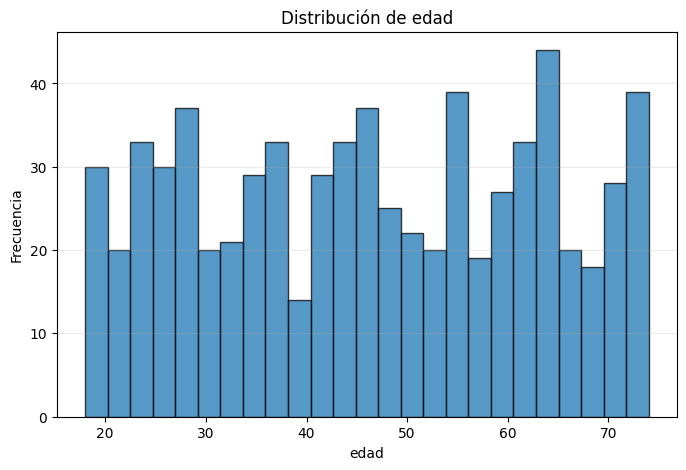

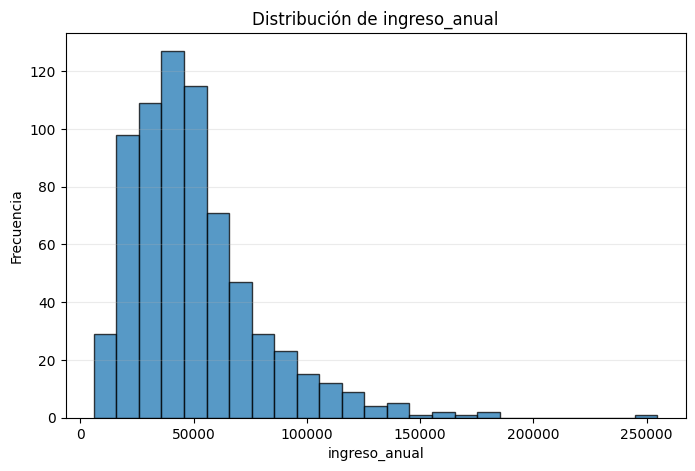

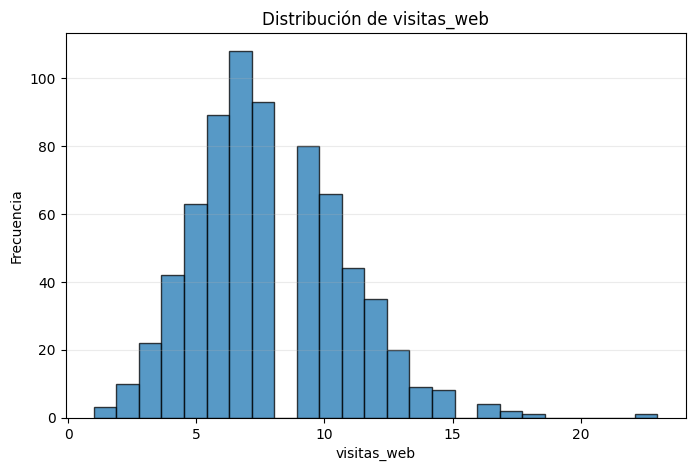

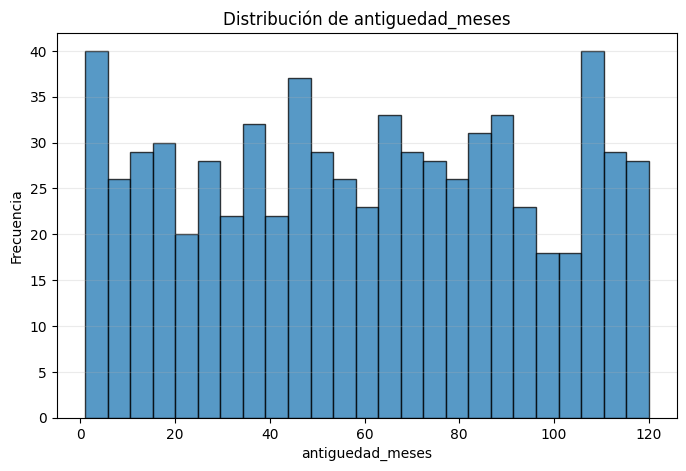

In [5]:
numeric_columns = [
    "edad",
    "ingreso_anual",
    "visitas_web",
    "antiguedad_meses",
]

for column in numeric_columns:
    plt.figure(figsize=(8, 5))
    plt.hist(data[column], bins=25, edgecolor="black", alpha=0.75)
    plt.xlabel(column)
    plt.ylabel("Frecuencia")
    plt.title(f"Distribución de {column}")
    plt.grid(axis="y", alpha=0.25)
    plt.show()


El ingreso presenta una distribución asimétrica. Una transformación logarítmica puede representar mejor cambios proporcionales que cambios absolutos.

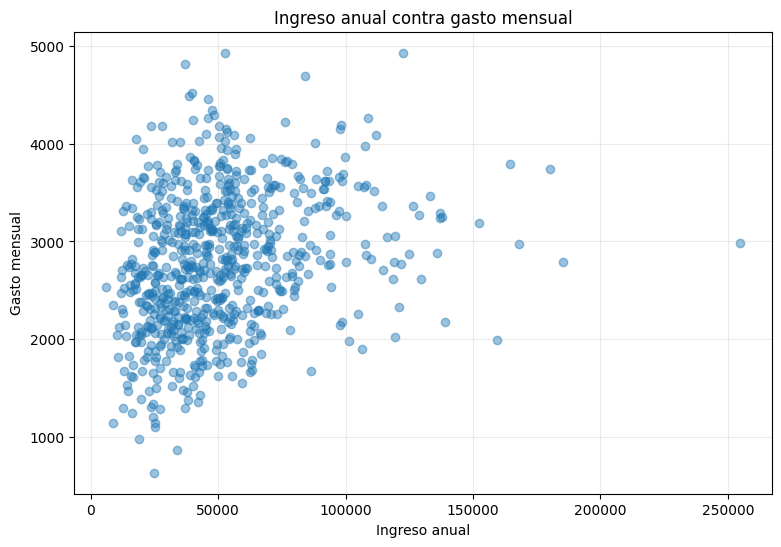

In [6]:
plt.figure(figsize=(9, 6))
plt.scatter(
    data["ingreso_anual"],
    data["gasto_mensual"],
    alpha=0.45,
)
plt.xlabel("Ingreso anual")
plt.ylabel("Gasto mensual")
plt.title("Ingreso anual contra gasto mensual")
plt.grid(alpha=0.25)
plt.show()


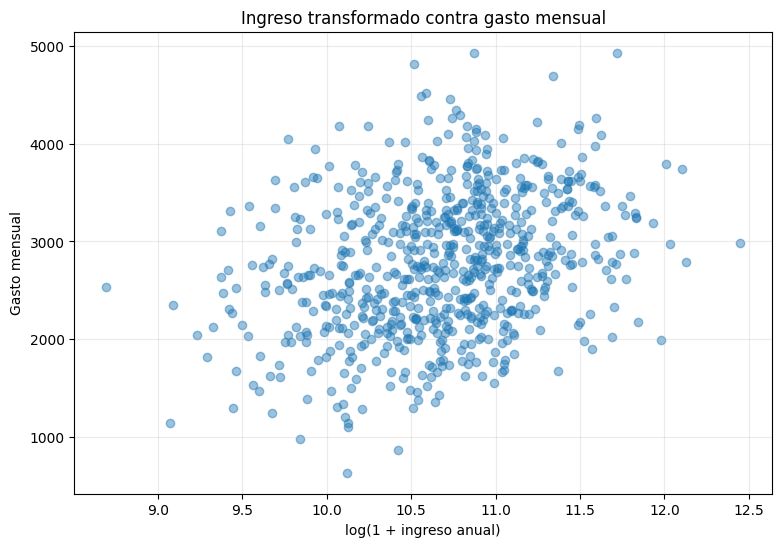

In [7]:
data["log_ingreso"] = np.log1p(data["ingreso_anual"])

plt.figure(figsize=(9, 6))
plt.scatter(
    data["log_ingreso"],
    data["gasto_mensual"],
    alpha=0.45,
)
plt.xlabel("log(1 + ingreso anual)")
plt.ylabel("Gasto mensual")
plt.title("Ingreso transformado contra gasto mensual")
plt.grid(alpha=0.25)
plt.show()


## 4. Split antes de aprender transformaciones

Primero separamos entrenamiento y prueba.

Las transformaciones que estiman parámetros —media, desviación estándar, mínimo, máximo, imputación— deben aprenderse únicamente con entrenamiento.

In [8]:
X = data.drop(columns=["gasto_mensual", "log_ingreso"])
y = data["gasto_mensual"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

print(X_train.shape, X_test.shape)


(525, 7) (175, 7)


## 5. Modelo base

Como referencia, construiremos un modelo sencillo utilizando únicamente variables numéricas originales.

In [9]:
base_numeric_features = [
    "edad",
    "ingreso_anual",
    "visitas_web",
    "antiguedad_meses",
]

base_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LinearRegression()),
])

base_model.fit(
    X_train[base_numeric_features],
    y_train,
)

base_predictions = base_model.predict(
    X_test[base_numeric_features]
)

base_metrics = pd.DataFrame({
    "Modelo": ["Modelo base"],
    "MAE": [mean_absolute_error(y_test, base_predictions)],
    "RMSE": [mean_squared_error(y_test, base_predictions) ** 0.5],
    "R²": [r2_score(y_test, base_predictions)],
})

base_metrics


,Modelo,MAE,RMSE,R²
0,Modelo base,325.550,412.915,0.678


## 6. Codificación de variables categóricas

Los modelos lineales no pueden operar directamente con etiquetas como `"Web"` o `"Premium"`.

Usaremos One-Hot Encoding:

- crea una columna binaria por categoría;
- evita imponer un orden artificial;
- permite manejar categorías nuevas mediante `handle_unknown="ignore"`.

In [10]:
categorical_features = [
    "canal",
    "region",
    "tipo_cliente",
]

categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent"),
    ),
    (
        "one_hot",
        OneHotEncoder(
            handle_unknown="ignore",
            drop=None,
            sparse_output=False,
        ),
    ),
])


## 7. Escalamiento de variables numéricas

### Estandarización

\[
z=\frac{x-\mu}{\sigma}.
\]

Produce variables aproximadamente centradas en cero y medidas en desviaciones estándar.

### Normalización Min-Max

Transforma los valores a un intervalo, normalmente \([0,1]\).

Para regresión lineal ordinaria, el escalamiento no cambia las predicciones si la especificación es equivalente. Sin embargo, es esencial para modelos penalizados y métodos basados en distancia.

In [11]:
numeric_transformer_standard = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

numeric_transformer_minmax = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler()),
])


## 8. Pipeline con variables numéricas y categóricas

`ColumnTransformer` permite aplicar transformaciones distintas según el tipo de columna.

In [12]:
preprocessor_basic = ColumnTransformer([
    (
        "numeric",
        numeric_transformer_standard,
        base_numeric_features,
    ),
    (
        "categorical",
        categorical_transformer,
        categorical_features,
    ),
])

model_with_categories = Pipeline([
    ("preprocessor", preprocessor_basic),
    ("model", LinearRegression()),
])

model_with_categories.fit(X_train, y_train)

category_predictions = model_with_categories.predict(X_test)

category_metrics = pd.DataFrame({
    "Modelo": ["Numéricas + categóricas"],
    "MAE": [mean_absolute_error(y_test, category_predictions)],
    "RMSE": [mean_squared_error(y_test, category_predictions) ** 0.5],
    "R²": [r2_score(y_test, category_predictions)],
})

category_metrics


,Modelo,MAE,RMSE,R²
0,Numéricas + categóricas,298.042,368.384,0.744


## 9. Variables derivadas

Una variable derivada combina o transforma información existente.

Crearemos:

- `log_ingreso`;
- `visitas_por_mes_cliente`;
- `interaccion_visitas_antiguedad`.

Estas variables reflejan conocimiento del proceso generador.

In [13]:
def add_derived_features(frame):
    result = frame.copy()

    result["log_ingreso"] = np.log1p(
        result["ingreso_anual"]
    )

    result["visitas_por_mes_cliente"] = (
        result["visitas_web"]
        / result["antiguedad_meses"].clip(lower=1)
    )

    result["interaccion_visitas_antiguedad"] = (
        result["visitas_web"]
        * result["antiguedad_meses"]
    )

    return result


X_train_engineered = add_derived_features(X_train)
X_test_engineered = add_derived_features(X_test)

X_train_engineered.head()


,edad,ingreso_anual,visitas_web,antiguedad_meses,canal,region,tipo_cliente,log_ingreso,visitas_por_mes_cliente,interaccion_visitas_antiguedad
163,41,"93,913.012",7,5,Tienda,Norte,Premium,11.450,1.400,35
286,27,"31,545.421",8,65,Tienda,Centro,Nuevo,10.359,0.123,520
613,39,"17,190.207",9,50,Web,Sur,Nuevo,9.752,0.180,450
518,45,"44,698.350",12,113,Marketplace,Centro,Recurrente,10.708,0.106,1356
464,18,"24,439.737",3,25,Tienda,Centro,Recurrente,10.104,0.120,75


Como estas transformaciones son determinísticas y no estiman parámetros globales, pueden aplicarse después del split sin fuga de información.

In [14]:
engineered_numeric_features = [
    "edad",
    "ingreso_anual",
    "log_ingreso",
    "visitas_web",
    "antiguedad_meses",
    "visitas_por_mes_cliente",
    "interaccion_visitas_antiguedad",
]

preprocessor_engineered = ColumnTransformer([
    (
        "numeric",
        numeric_transformer_standard,
        engineered_numeric_features,
    ),
    (
        "categorical",
        categorical_transformer,
        categorical_features,
    ),
])

engineered_model = Pipeline([
    ("preprocessor", preprocessor_engineered),
    ("model", LinearRegression()),
])

engineered_model.fit(
    X_train_engineered,
    y_train,
)

engineered_predictions = engineered_model.predict(
    X_test_engineered
)

engineered_metrics = pd.DataFrame({
    "Modelo": ["Ingeniería de variables"],
    "MAE": [mean_absolute_error(y_test, engineered_predictions)],
    "RMSE": [mean_squared_error(y_test, engineered_predictions) ** 0.5],
    "R²": [r2_score(y_test, engineered_predictions)],
})

engineered_metrics


,Modelo,MAE,RMSE,R²
0,Ingeniería de variables,294.169,363.356,0.751


## 10. Variables polinomiales e interacciones automáticas

`PolynomialFeatures` puede generar:

- cuadrados;
- productos entre variables;
- términos de mayor grado.

Para mantener el ejemplo interpretable, aplicaremos grado 2 únicamente a dos variables.

In [15]:
interaction_features = [
    "visitas_web",
    "antiguedad_meses",
]

other_numeric_features = [
    "edad",
    "ingreso_anual",
]

interaction_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    (
        "polynomial",
        PolynomialFeatures(
            degree=2,
            include_bias=False,
        ),
    ),
    ("scaler", StandardScaler()),
])

preprocessor_polynomial = ColumnTransformer([
    (
        "interaction_block",
        interaction_transformer,
        interaction_features,
    ),
    (
        "other_numeric",
        numeric_transformer_standard,
        other_numeric_features,
    ),
    (
        "categorical",
        categorical_transformer,
        categorical_features,
    ),
])

polynomial_model = Pipeline([
    ("preprocessor", preprocessor_polynomial),
    ("model", LinearRegression()),
])

polynomial_model.fit(X_train, y_train)

polynomial_predictions = polynomial_model.predict(X_test)

polynomial_metrics = pd.DataFrame({
    "Modelo": ["Polinomios e interacciones"],
    "MAE": [mean_absolute_error(y_test, polynomial_predictions)],
    "RMSE": [mean_squared_error(y_test, polynomial_predictions) ** 0.5],
    "R²": [r2_score(y_test, polynomial_predictions)],
})

polynomial_metrics


,Modelo,MAE,RMSE,R²
0,Polinomios e interacciones,299.909,368.728,0.743


Agregar términos automáticamente puede mejorar el ajuste, pero también:

- aumenta la dimensionalidad;
- dificulta la interpretación;
- eleva el riesgo de overfitting;
- puede generar colinealidad.

Debe usarse con validación y criterio sustantivo.

## 11. Comparación de modelos

In [16]:
model_comparison = pd.concat(
    [
        base_metrics,
        category_metrics,
        engineered_metrics,
        polynomial_metrics,
    ],
    ignore_index=True,
)

model_comparison.sort_values("RMSE")


,Modelo,MAE,RMSE,R²
2,Ingeniería de variables,294.169,363.356,0.751
1,Numéricas + categóricas,298.042,368.384,0.744
3,Polinomios e interacciones,299.909,368.728,0.743
0,Modelo base,325.550,412.915,0.678


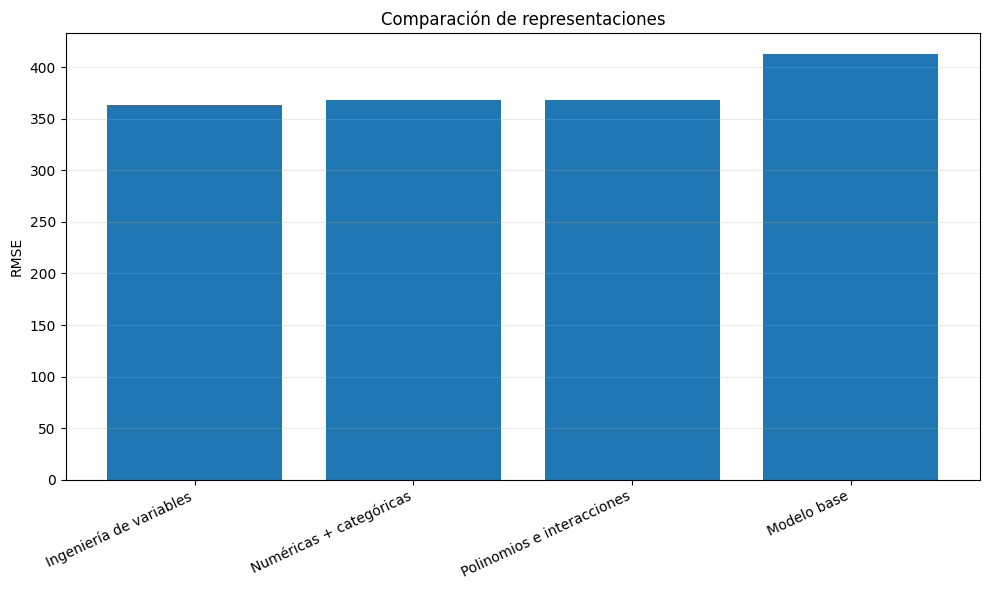

In [17]:
plt.figure(figsize=(10, 6))

ordered_results = model_comparison.sort_values("RMSE")

plt.bar(
    ordered_results["Modelo"],
    ordered_results["RMSE"],
)

plt.ylabel("RMSE")
plt.title("Comparación de representaciones")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


La comparación permite observar que un algoritmo sencillo puede mejorar considerablemente cuando recibe una representación más adecuada.

La ingeniería de variables no consiste en crear variables indiscriminadamente. Consiste en representar mejor el problema.

## 12. Inspección de las variables transformadas

Podemos consultar los nombres producidos por el preprocesador.

In [18]:
feature_names = (
    engineered_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

print(f"Número de variables después del preprocesamiento: {len(feature_names)}")
feature_names[:20]


Número de variables después del preprocesamiento: 16


array(['numeric__edad', 'numeric__ingreso_anual', 'numeric__log_ingreso',
       'numeric__visitas_web', 'numeric__antiguedad_meses',
       'numeric__visitas_por_mes_cliente',
       'numeric__interaccion_visitas_antiguedad',
       'categorical__canal_Marketplace', 'categorical__canal_Tienda',
       'categorical__canal_Web', 'categorical__region_Centro',
       'categorical__region_Norte', 'categorical__region_Sur',
       'categorical__tipo_cliente_Nuevo',
       'categorical__tipo_cliente_Premium',
       'categorical__tipo_cliente_Recurrente'], dtype=object)

In [19]:
coefficient_table = pd.DataFrame({
    "Variable transformada": feature_names,
    "Coeficiente": engineered_model.named_steps["model"].coef_,
})

coefficient_table["Magnitud absoluta"] = (
    coefficient_table["Coeficiente"].abs()
)

coefficient_table.sort_values(
    "Magnitud absoluta",
    ascending=False,
).head(15)


,Variable transformada,Coeficiente,Magnitud absoluta
14,categorical__tipo_cliente_Premium,394.001,394.001
13,categorical__tipo_cliente_Nuevo,-305.823,305.823
0,numeric__edad,294.701,294.701
4,numeric__antiguedad_meses,235.174,235.174
3,numeric__visitas_web,172.408,172.408
2,numeric__log_ingreso,156.452,156.452
7,categorical__canal_Marketplace,-154.896,154.896
6,numeric__interaccion_visitas_antiguedad,134.894,134.894
8,categorical__canal_Tienda,128.419,128.419
12,categorical__region_Sur,-107.311,107.311


Los coeficientes deben interpretarse considerando:

- escalamiento;
- codificación;
- categoría de referencia implícita;
- presencia de interacciones;
- correlación entre variables.

Una gran magnitud no implica causalidad.

## 13. Data Leakage

La fuga de información ocurre cuando el pipeline utiliza información que no estaría disponible al momento de predecir o cuando aprende transformaciones usando datos de test.

### Ejemplo incorrecto

```python
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test = train_test_split(X_scaled)
```

El escalador ya utilizó información de todo el dataset.

### Forma correcta

```python
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])
pipeline.fit(X_train, y_train)
```

El escalador aprende únicamente con entrenamiento.

## 14. Categorías desconocidas

Gracias a:

```python
OneHotEncoder(handle_unknown="ignore")
```

el pipeline puede recibir una categoría no observada durante entrenamiento sin fallar.

La nueva categoría se representa con ceros en las columnas conocidas. Esto evita un error técnico, aunque no garantiza una buena predicción.

In [20]:
example_new_customer = pd.DataFrame({
    "edad": [35],
    "ingreso_anual": [480_000],
    "visitas_web": [10],
    "antiguedad_meses": [18],
    "canal": ["Aplicación"],  # Categoría no observada
    "region": ["Centro"],
    "tipo_cliente": ["Recurrente"],
})

example_engineered = add_derived_features(
    example_new_customer
)

prediction_new_customer = engineered_model.predict(
    example_engineered
)[0]

print(
    f"Predicción para el nuevo cliente: "
    f"{prediction_new_customer:,.2f}"
)


Predicción para el nuevo cliente: 3,439.41


## 15. Errores frecuentes

1. Codificar categorías ordinales como si fueran nominales, o viceversa.
2. Ajustar transformaciones antes del split.
3. Crear variables utilizando información futura.
4. Aplicar logaritmos sin revisar ceros o valores negativos.
5. Generar miles de interacciones sin validación.
6. Interpretar coeficientes sin considerar el escalamiento.
7. Incluir identificadores como variables predictoras.
8. Transformar train y test con procedimientos diferentes.
9. No manejar categorías desconocidas.
10. Confundir una mejora in-sample con una mejora de generalización.

## 16. Experimentos sugeridos

### Experimento 1

Compara `StandardScaler` y `MinMaxScaler`.

### Experimento 2

Elimina las variables categóricas y observa el cambio en desempeño.

### Experimento 3

Elimina la interacción entre visitas y antigüedad.

### Experimento 4

Incrementa el grado de `PolynomialFeatures` a 3 o 4.

### Experimento 5

Agrega valores faltantes aleatoriamente y verifica que el pipeline pueda imputarlos.

### Experimento 6

Cambia `drop=None` por `drop="first"` en `OneHotEncoder`.

### Experimento 7

Agrega una variable identificadora aleatoria y analiza por qué no debería utilizarse.

### Experimento 8

Construye una variable que use información de la variable objetivo y explica por qué representa leakage.

## 17. Resumen

En este notebook:

- exploramos variables numéricas y categóricas;
- aplicamos One-Hot Encoding;
- revisamos estandarización y Min-Max;
- construimos variables derivadas;
- generamos interacciones y polinomios;
- utilizamos `ColumnTransformer` y `Pipeline`;
- evitamos Data Leakage;
- manejamos categorías desconocidas;
- comparamos distintas representaciones de los datos.

La calidad de un modelo depende tanto del algoritmo como de la forma en que representamos la información.